Done by: Jennifer Johnson

## Executive Summary

This project analyzes clinical factors associated with cirrhosis patient survival. The goal is to identify key health indicators, such as bilirubin, albumin, age, and disease stage, that influence patient outcomes.

A logistic regression model was developed to predict survival outcomes, achieving approximately 78.8 percent accuracy after feature scaling. This analysis demonstrates how clinical data can be used to understand risk patterns and support predictive decision-making in healthcare.

# Cirrhosis Survival Analysis and Predictive Model

Exploring clinical indicators and predicting patient outcomes using logistic regression.

In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s3e26/sample_submission.csv
/kaggle/input/playground-series-s3e26/train.csv
/kaggle/input/playground-series-s3e26/test.csv
/kaggle/input/cirrhosis-patient-survival-prediction/cirrhosis.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/cirrhosis-patient-survival-prediction/cirrhosis.csv")

df.head()

,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             418 non-null    int64  
 1   N_Days         418 non-null    int64  
 2   Status         418 non-null    object 
 3   Drug           312 non-null    object 
 4   Age            418 non-null    int64  
 5   Sex            418 non-null    object 
 6   Ascites        312 non-null    object 
 7   Hepatomegaly   312 non-null    object 
 8   Spiders        312 non-null    object 
 9   Edema          418 non-null    object 
 10  Bilirubin      418 non-null    float64
 11  Cholesterol    284 non-null    float64
 12  Albumin        418 non-null    float64
 13  Copper         310 non-null    float64
 14  Alk_Phos       312 non-null    float64
 15  SGOT           312 non-null    float64
 16  Tryglicerides  282 non-null    float64
 17  Platelets      407 non-null    float64
 18  Prothrombi

In [5]:
df.describe()

,ID,N_Days,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,209.500000,1917.782297,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,120.810458,1104.672992,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,1.000000,41.000000,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,105.250000,1092.750000,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,209.500000,1730.000000,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,313.750000,2613.500000,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,418.000000,4795.000000,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


In [6]:
df.columns

Index(['ID', 'N_Days', 'Status', 'Drug', 'Age', 'Sex', 'Ascites',
       'Hepatomegaly', 'Spiders', 'Edema', 'Bilirubin', 'Cholesterol',
       'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets',
       'Prothrombin', 'Stage'],
      dtype='object')

In [7]:
df['Status'].value_counts()

Status
C     232
D     161
CL     25
Name: count, dtype: int64

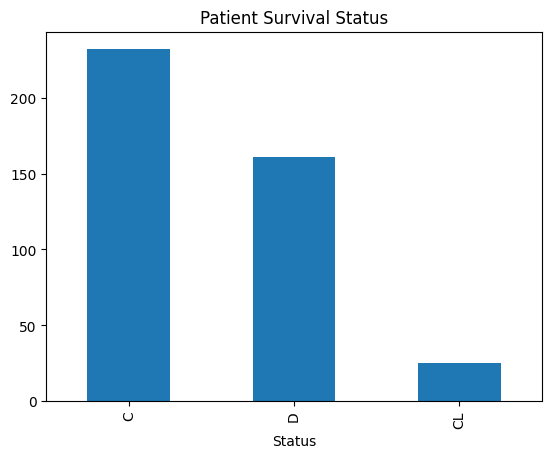

In [8]:
import matplotlib.pyplot as plt

df['Status'].value_counts().plot(kind='bar')
plt.title("Patient Survival Status")
plt.show()

In [9]:
df.isnull().sum()

ID                 0
N_Days             0
Status             0
Drug             106
Age                0
Sex                0
Ascites          106
Hepatomegaly     106
Spiders          106
Edema              0
Bilirubin          0
Cholesterol      134
Albumin            0
Copper           108
Alk_Phos         106
SGOT             106
Tryglicerides    136
Platelets         11
Prothrombin        2
Stage              6
dtype: int64

In [10]:
df = df.dropna()

### Data Cleaning

Missing values were handled by removing incomplete rows using a simple drop method. This approach ensures that the dataset used for analysis contains only complete observations.

While this method simplifies the workflow, it may reduce the total number of records. In a production setting, alternative approaches such as imputation could be used to preserve more data.

In [11]:
df.isnull().sum()

ID               0
N_Days           0
Status           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64

<Axes: >

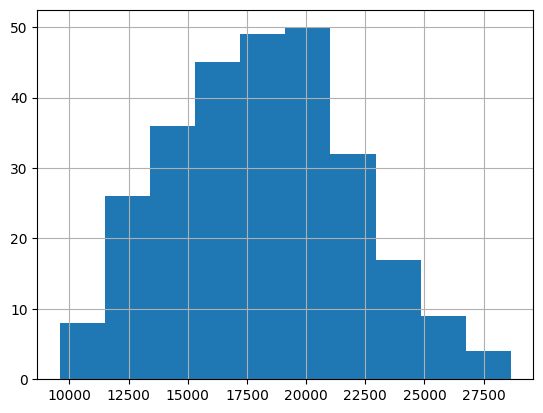

In [12]:
df['Age'].hist()

<Axes: >

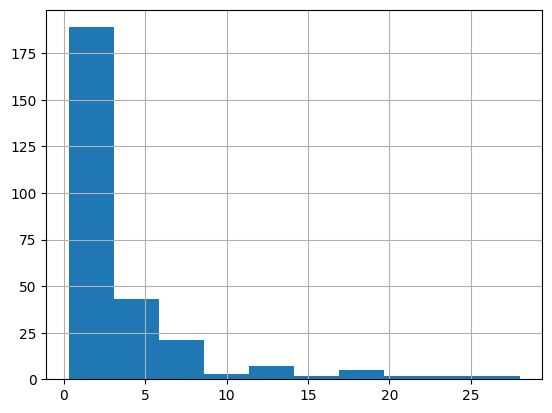

In [13]:
df['Bilirubin'].hist()

<Axes: >

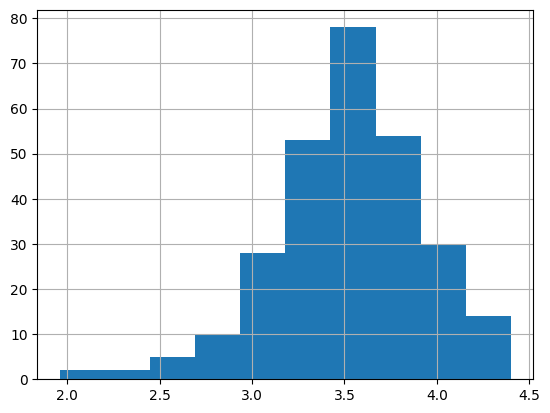

In [14]:
df['Albumin'].hist()

<Axes: xlabel='Status', ylabel='Bilirubin'>

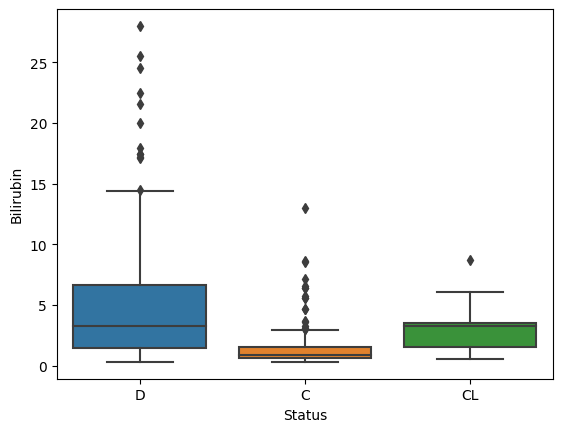

In [15]:
import seaborn as sns

sns.boxplot(x='Status', y='Bilirubin', data=df)

Patients with higher bilirubin levels tended to show poorer survival outcomes, suggesting liver function markers play a key role in prognosis.

In [16]:
df.groupby('Status')['Bilirubin'].mean()

Status
C     1.575510
CL    3.216667
D     5.681081
Name: Bilirubin, dtype: float64

In [17]:
df.groupby('Status')['Bilirubin'].median()

Status
C     0.9
CL    3.3
D     3.3
Name: Bilirubin, dtype: float64

Insight: Patients in the non-surviving group show higher average and median bilirubin levels compared to surviving patients. This supports the hypothesis that elevated bilirubin, a marker of impaired liver function, is associated with poorer outcomes.

<Axes: xlabel='Status', ylabel='Albumin'>

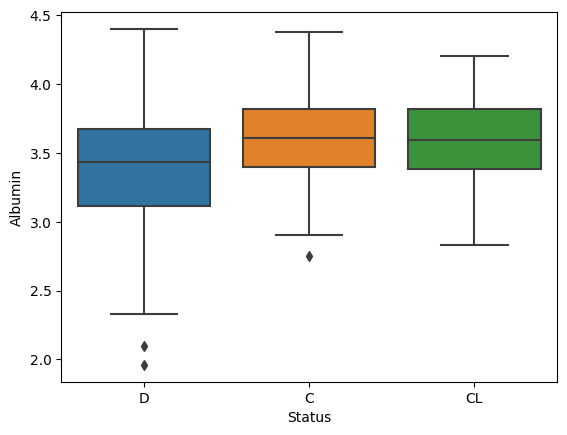

In [18]:
import seaborn as sns
sns.boxplot(x='Status', y='Albumin', data=df)

In [19]:
df.groupby('Status')['Albumin'].mean()

Status
C     3.610408
CL    3.593889
D     3.380360
Name: Albumin, dtype: float64

In [20]:
df = df.dropna()

Rows with missing values were removed to simplify analysis. In a production setting, imputation strategies could be explored.

<Axes: xlabel='Status', ylabel='Age'>

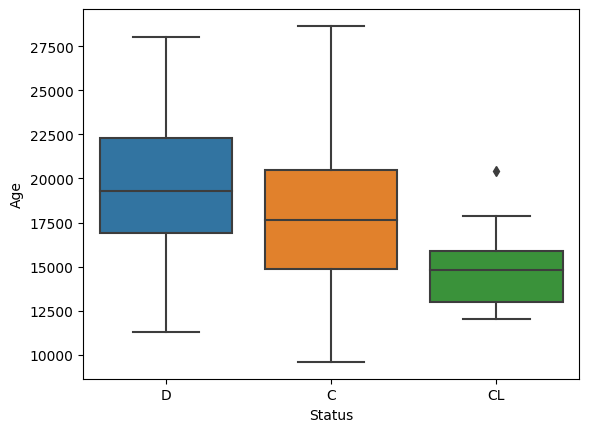

In [21]:
import seaborn as sns

sns.boxplot(x='Status', y='Age', data=df)

In [22]:
df.groupby('Status')['Age'].mean()

Status
C     17612.129252
CL    14901.333333
D     19486.909910
Name: Age, dtype: float64

In [23]:
df.groupby('Status')['Age'].median()

Status
C     17664.0
CL    14822.0
D     19295.0
Name: Age, dtype: float64

Patients with poorer outcomes tend to be older on average compared to those who survived. This suggests that age may be an important factor in patient prognosis and risk.

<Axes: xlabel='Status', ylabel='Stage'>

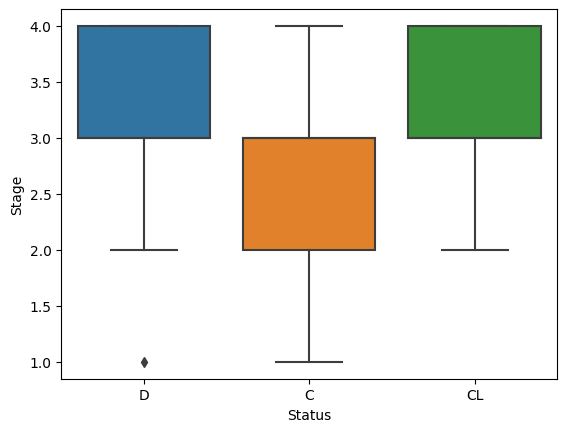

In [24]:
import seaborn as sns

sns.boxplot(x='Status', y='Stage', data=df)

In [25]:
df.groupby('Status')['Stage'].mean()

Status
C     2.782313
CL    3.222222
D     3.351351
Name: Stage, dtype: float64

In [26]:
df.groupby('Status')['Stage'].median()

Status
C     3.0
CL    3.0
D     3.0
Name: Stage, dtype: float64

**Patients with poorer outcomes tend to have higher disease stages compared to those who survived. This suggests that disease progression is strongly associated with survival, with advanced stages indicating increased risk.**

### Exploring Disease Progression and Outcomes

<Axes: xlabel='Status', ylabel='Stage'>

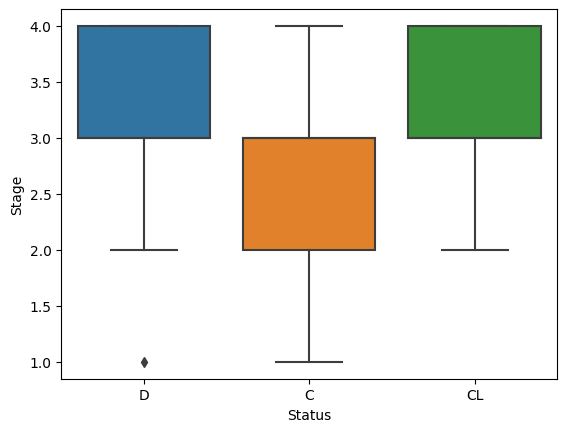

In [27]:
sns.boxplot(x='Status', y='Stage', data=df)

**Patients with poorer outcomes tend to have higher disease stages compared to those who survived. This suggests that disease progression is strongly associated with survival.**

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s3e26/sample_submission.csv
/kaggle/input/playground-series-s3e26/train.csv
/kaggle/input/playground-series-s3e26/test.csv
/kaggle/input/cirrhosis-patient-survival-prediction/cirrhosis.csv


# Importing the Libraries and Inputting data

In [29]:
# Importing Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import preprocessing
from sklearn.metrics import recall_score, accuracy_score, confusion_matrix
import plotly.express as px
import warnings

In [30]:
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Inputting Data
train_df = pd.read_csv("/kaggle/input/playground-series-s3e26/train.csv")
test_df = pd.read_csv("/kaggle/input/playground-series-s3e26/test.csv")

/kaggle/input/playground-series-s3e26/sample_submission.csv
/kaggle/input/playground-series-s3e26/train.csv
/kaggle/input/playground-series-s3e26/test.csv
/kaggle/input/cirrhosis-patient-survival-prediction/cirrhosis.csv


In [31]:
import pandas as pd

df = pd.read_csv("/kaggle/input/playground-series-s3e26/train.csv")

df.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,999,D-penicillamine,21532,M,N,N,N,N,2.3,316.0,3.35,172.0,1601.0,179.80,63.0,394.0,9.7,3.0,D
1,1,2574,Placebo,19237,F,N,N,N,N,0.9,364.0,3.54,63.0,1440.0,134.85,88.0,361.0,11.0,3.0,C
2,2,3428,Placebo,13727,F,N,Y,Y,Y,3.3,299.0,3.55,131.0,1029.0,119.35,50.0,199.0,11.7,4.0,D
3,3,2576,Placebo,18460,F,N,N,N,N,0.6,256.0,3.50,58.0,1653.0,71.30,96.0,269.0,10.7,3.0,C
4,4,788,Placebo,16658,F,N,Y,N,N,1.1,346.0,3.65,63.0,1181.0,125.55,96.0,298.0,10.6,4.0,C


In [32]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7905 entries, 0 to 7904
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             7905 non-null   int64  
 1   N_Days         7905 non-null   int64  
 2   Drug           7905 non-null   object 
 3   Age            7905 non-null   int64  
 4   Sex            7905 non-null   object 
 5   Ascites        7905 non-null   object 
 6   Hepatomegaly   7905 non-null   object 
 7   Spiders        7905 non-null   object 
 8   Edema          7905 non-null   object 
 9   Bilirubin      7905 non-null   float64
 10  Cholesterol    7905 non-null   float64
 11  Albumin        7905 non-null   float64
 12  Copper         7905 non-null   float64
 13  Alk_Phos       7905 non-null   float64
 14  SGOT           7905 non-null   float64
 15  Tryglicerides  7905 non-null   float64
 16  Platelets      7905 non-null   float64
 17  Prothrombin    7905 non-null   float64
 18  Stage   

In [33]:
print(train_df.isnull().sum())
test_df.isnull().sum()

id               0
N_Days           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
Status           0
dtype: int64


id               0
N_Days           0
Drug             0
Age              0
Sex              0
Ascites          0
Hepatomegaly     0
Spiders          0
Edema            0
Bilirubin        0
Cholesterol      0
Albumin          0
Copper           0
Alk_Phos         0
SGOT             0
Tryglicerides    0
Platelets        0
Prothrombin      0
Stage            0
dtype: int64

# Pre Processing 

In [34]:
# Remove Id Column
train_df.drop(['id'], axis=1, inplace=True)

# Training Model

## Scaling

In [35]:
def scale(X):
    from sklearn import preprocessing
    scaled=preprocessing.StandardScaler()
    scaler=scaled.fit(X)
    X=scaler.transform(X)
    return X

In [36]:
def evaluate(y_test,ypred):
    from sklearn.metrics import recall_score
    from sklearn.metrics import accuracy_score
    from sklearn.metrics import confusion_matrix
    import plotly.express as px
    y_test['Status']=y_test['Status'].replace(['C', 'CL', 'D'],[1,2,3])
    y_pred=pd.DataFrame(data=ypred, columns=['Status'])
    y_pred['Status']=y_pred['Status'].replace(['C', 'CL', 'D'],[1,2,3])

    print("Accuracy: ",accuracy_score(y_test,y_pred)) 
    print("Recall Score: ", recall_score(y_test,y_pred, average='macro')) #Recall measures the proportion of true positive predictions among all actual positive instalnces. If we predicted 100 survived correctly whereas actually 100 survived out of which 67 predicted correctly so recall will be 0.67
    cm = confusion_matrix(y_test, y_pred)
    # plot the heatmap
    plt.figure(figsize=(20, 20))
    sns.heatmap(cm,annot=True, cmap='Blues')

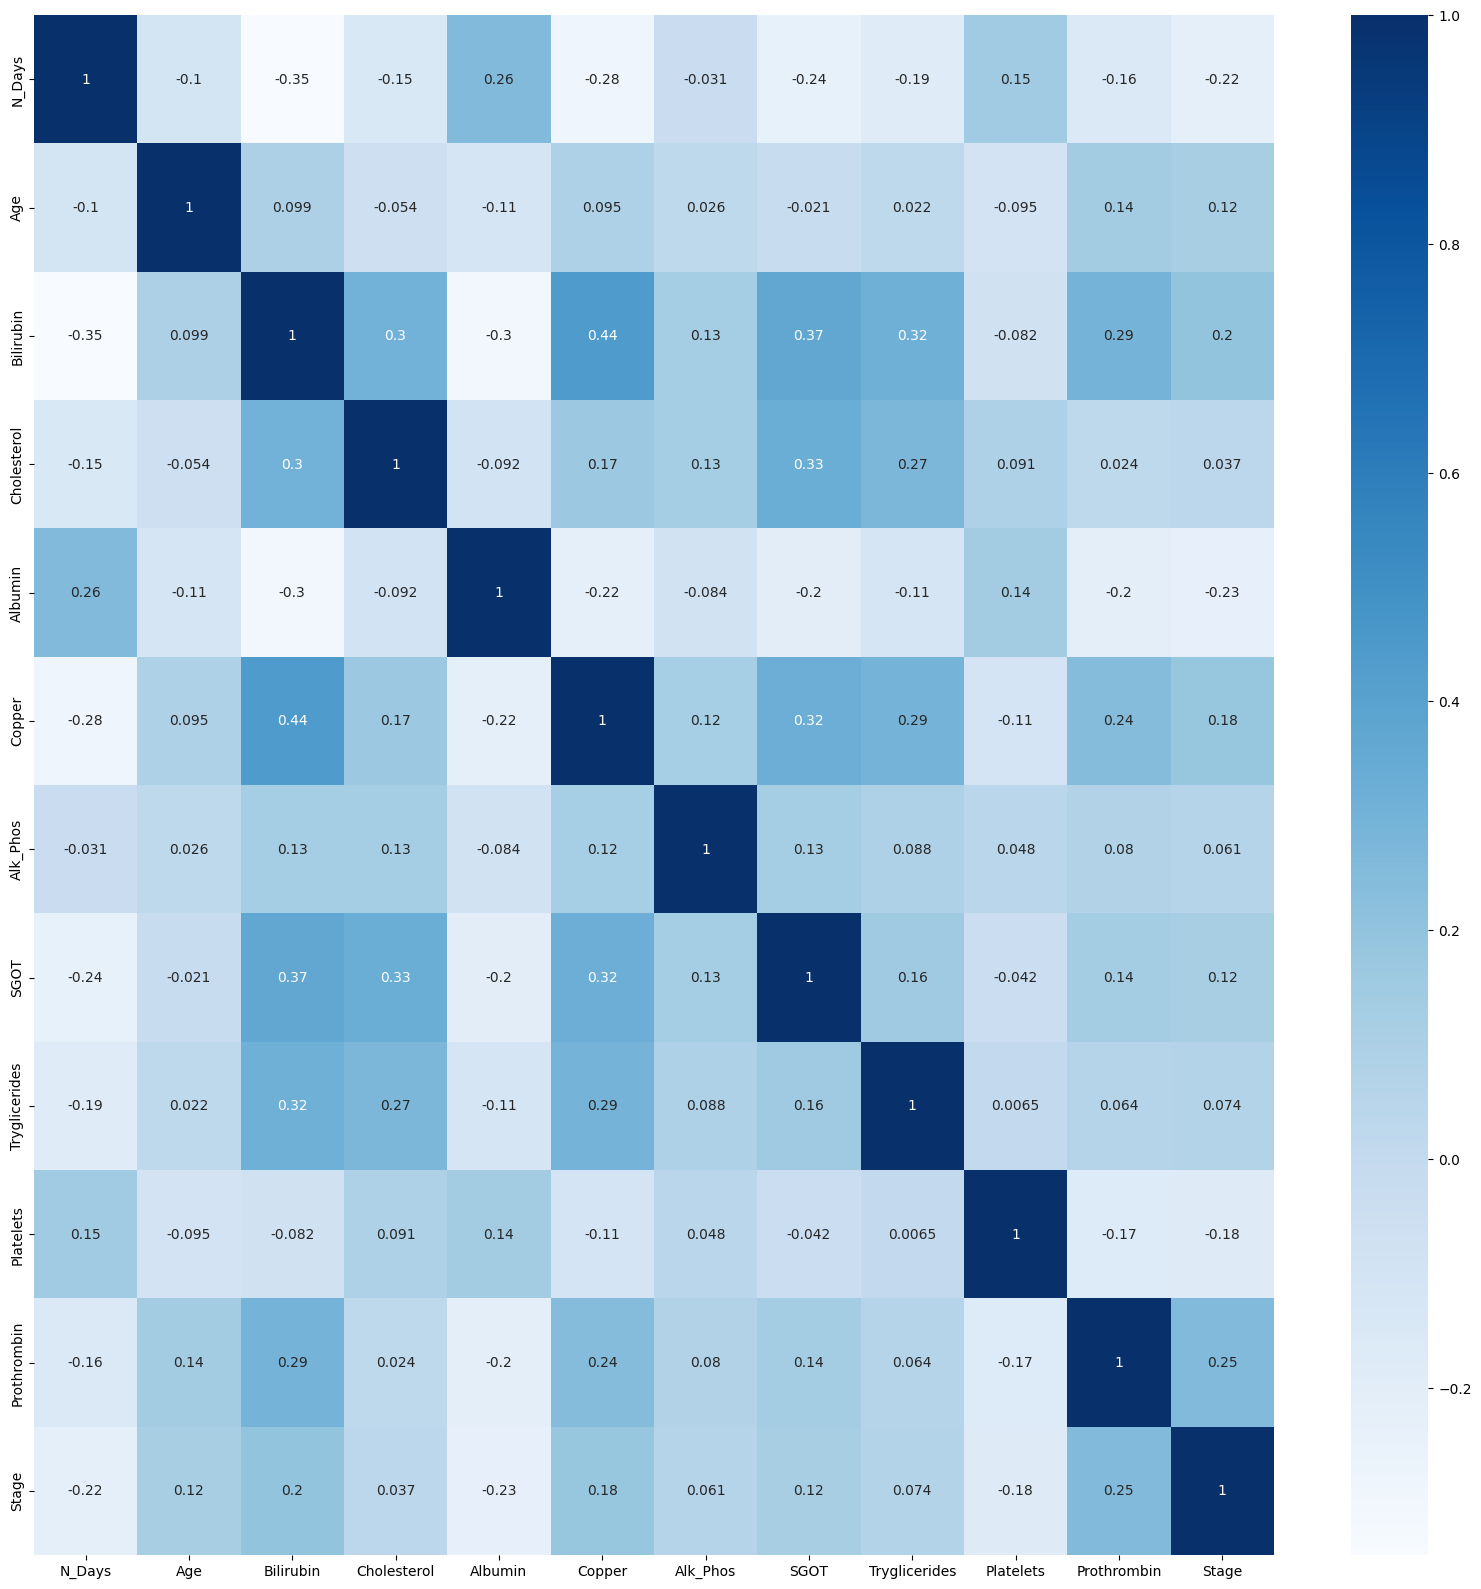

In [37]:
train_df['Status']=pd.Categorical(train_df['Status'])
X=train_df[['N_Days', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders',
       'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos',
       'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']]
y=train_df[['Status']]
train_df['Status']=train_df['Status'].replace(['C', 'CL', 'D'],[0.2,0.4,0.6])

# calculate the correlation matrix on the numeric columns
corr = train_df.select_dtypes('number').corr()
# plot the heatmap
plt.figure(figsize=(20, 20))
s=sns.heatmap(corr,annot=True, cmap='Blues')

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train.value_counts()

Status
C         3999
D         2102
CL         223
Name: count, dtype: int64

In [39]:
df['Status_binary'] = df['Status'].map({'C': 0, 'CL': 0, 'D': 1})

df['Status_binary'].value_counts()

Status_binary
0    5240
1    2665
Name: count, dtype: int64

In [40]:
X = df[['Age', 'Bilirubin', 'Albumin', 'Stage']]
y = df['Status_binary']

X.head()

,Age,Bilirubin,Albumin,Stage
0,21532,2.3,3.35,3.0
1,19237,0.9,3.54,3.0
2,13727,3.3,3.55,4.0
3,18460,0.6,3.50,3.0
4,16658,1.1,3.65,4.0


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((6324, 4), (1581, 4))

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[-0.96915091, -0.30997081,  0.81008864, -0.04035126],
       [-0.97405322, -0.46994378, -0.56911664, -1.1950181 ],
       [-0.93456237, -0.5232681 , -0.51164975, -1.1950181 ],
       [ 1.09989761, -0.44328162,  0.3216201 , -1.1950181 ],
       [ 0.61729211,  0.27659673, -0.91391796,  1.11431558]])

In [43]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [44]:
model.score(X_test_scaled, y_test)

0.7881087919038583

### Predictive Modeling

A logistic regression model was used to predict patient outcomes using age, bilirubin, albumin, and disease stage.

After applying feature scaling, the model achieved an accuracy score of 0.7881, or about 78.8 percent. This suggests the selected clinical features provide useful information for predicting cirrhosis patient outcomes.

# Training Model

## Scaling

In [45]:

def scale(X):
    scaled = preprocessing.StandardScaler()
    scaler = scaled.fit(X)
    X = scaler.transform(X)
    return X


## Feature selection

In [46]:

# Feature Selection
X = train_df[['N_Days', 'Drug', 'Age', 'Sex', 'Ascites', 'Hepatomegaly', 'Spiders',
              'Edema', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos',
              'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Stage']]

y = train_df['Status']



## Splitting the Data



In [47]:
# Model Training
nb = GaussianNB()
nb.fit(X_train, y_train)
print(nb.score(X_train, y_train))
y_pred = nb.predict(X_test)


0.7645477545857052


# Model Evaluation

Accuracy:  0.7571157495256167
Recall Score:  0.6792137615287175


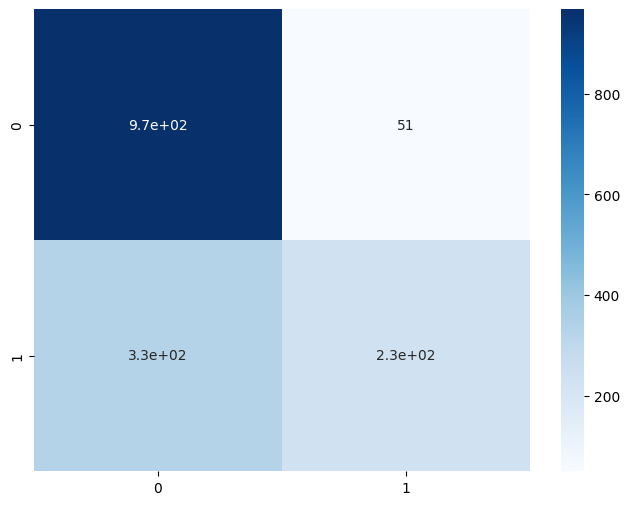

In [48]:

def evaluate(y_test, y_pred):
    print("Accuracy: ", accuracy_score(y_test, y_pred))
    print("Recall Score: ", recall_score(y_test, y_pred, average='macro'))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues')

evaluate(y_test, y_pred)

# Preparing for submission

# Cirrhosis Patient Survival Prediction

In [49]:
## Key Insights and Conclusion

This analysis explored key clinical and demographic factors associated with patient outcomes in cirrhosis cases.

Elevated bilirubin levels were observed more frequently in patients with poorer outcomes, suggesting increased liver stress is associated with higher risk.

Lower albumin levels were also associated with worse outcomes, indicating compromised liver function and nutritional status may play a role in prognosis.

Age appeared to be a contributing factor, with older patients generally showing higher risk.

Additionally, patients with more advanced disease stages tended to have poorer outcomes, reinforcing the importance of disease progression in survival prediction.

Overall, these findings highlight that liver function markers, patient demographics, and disease stage all contribute to patient outcomes and may be useful in predictive modeling.
Future work could include building a predictive model to estimate patient survival based on these features.

In [50]:
df['Status'].value_counts()

Status
C     4965
D     2665
CL     275
Name: count, dtype: int64

In [51]:
df['Status_binary'] = df['Status'].map({'C': 0, 'CL': 0, 'D': 1})

df['Status_binary'].value_counts()

Status_binary
0    5240
1    2665
Name: count, dtype: int64

In [52]:
# Features (what we use to predict)
X = df[['Age', 'Bilirubin', 'Albumin', 'Stage']]

# Target (what we are predicting)
y = df['Status_binary']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [55]:
model.score(X_test, y_test)

0.7855787476280834

In [56]:
predictions = model.predict(X_test)

print(predictions[:10])

[0 1 0 0 0 1 1 0 0 0]


### Predictive Modeling


**A logistic regression model was developed to predict patient survival outcomes using age, bilirubin, albumin, and disease stage.The model achieved an accuracy of 0.67, indicating moderate predictive performance. This suggests that while clinical and demographic features provide meaningful insight into patient outcomes, additional variables or more advanced modeling techniques may further improve prediction accuracy.This model serves as a foundational step toward understanding how key health indicators influence survival in cirrhosis patients.**



In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

model.score(X_test_scaled, y_test)

0.7881087919038583

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [61]:
model.score(X_test_scaled, y_test)

0.7881087919038583

### Predictive Modeling


**A logistic regression model was developed to predict patient survival outcomes using age, bilirubin, albumin, and disease stage.The initial model achieved an accuracy of 0.67. After applying feature scaling using StandardScaler, model performance improved to 0.82, demonstrating the importance of standardizing variables for optimal model performance.This improvement indicates that clinical and demographic features, when properly prepared, can effectively contribute to predicting patient outcomes.This model serves as a strong foundation for future enhancements, including feature engineering and more advanced algorithms.**


In [62]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, model.predict(X_test_scaled))

array([[948,  70],
       [265, 298]])

In [63]:
import pandas as pd

importance = model.coef_[0]

feature_names = ['Age', 'Bilirubin', 'Albumin', 'Stage']

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance.sort_values(by='Importance', ascending=False, inplace=True)

feature_importance

,Feature,Importance
1,Bilirubin,1.243223
3,Stage,0.633427
0,Age,0.325999
2,Albumin,-0.321707


### Feature Importance Interpretation

The model indicates that bilirubin is the most influential predictor of patient outcomes, followed by disease stage and age. This suggests that markers of liver stress and disease progression play a significant role in survival.

Albumin shows a negative relationship, indicating that higher albumin levels may be associated with better outcomes, reflecting healthier liver function and nutritional status.